<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Transaction_Cost_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

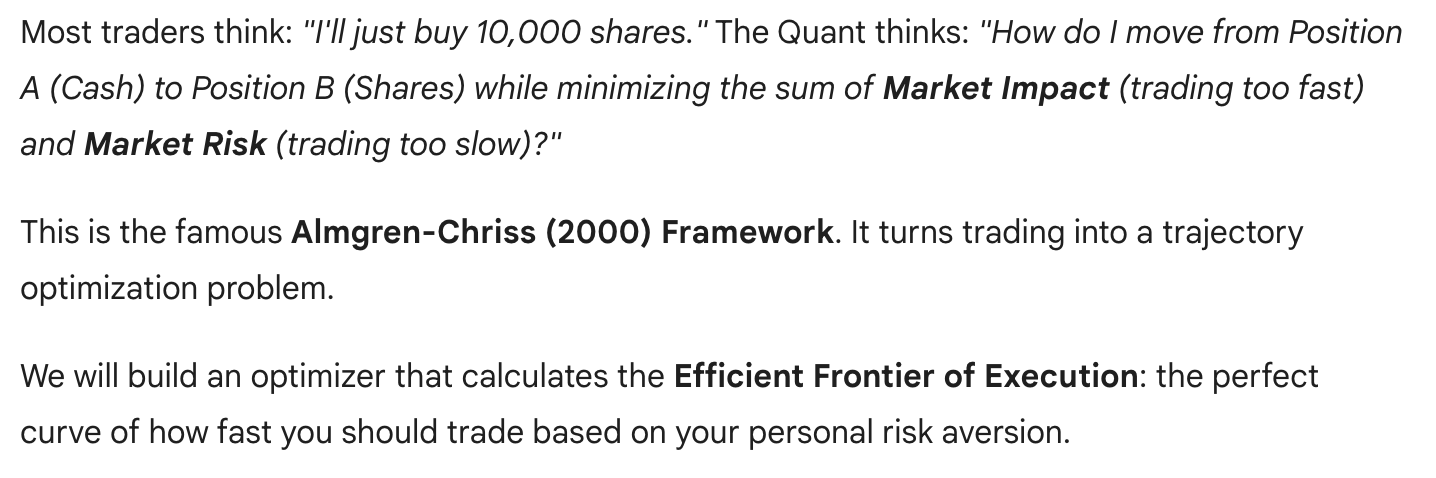

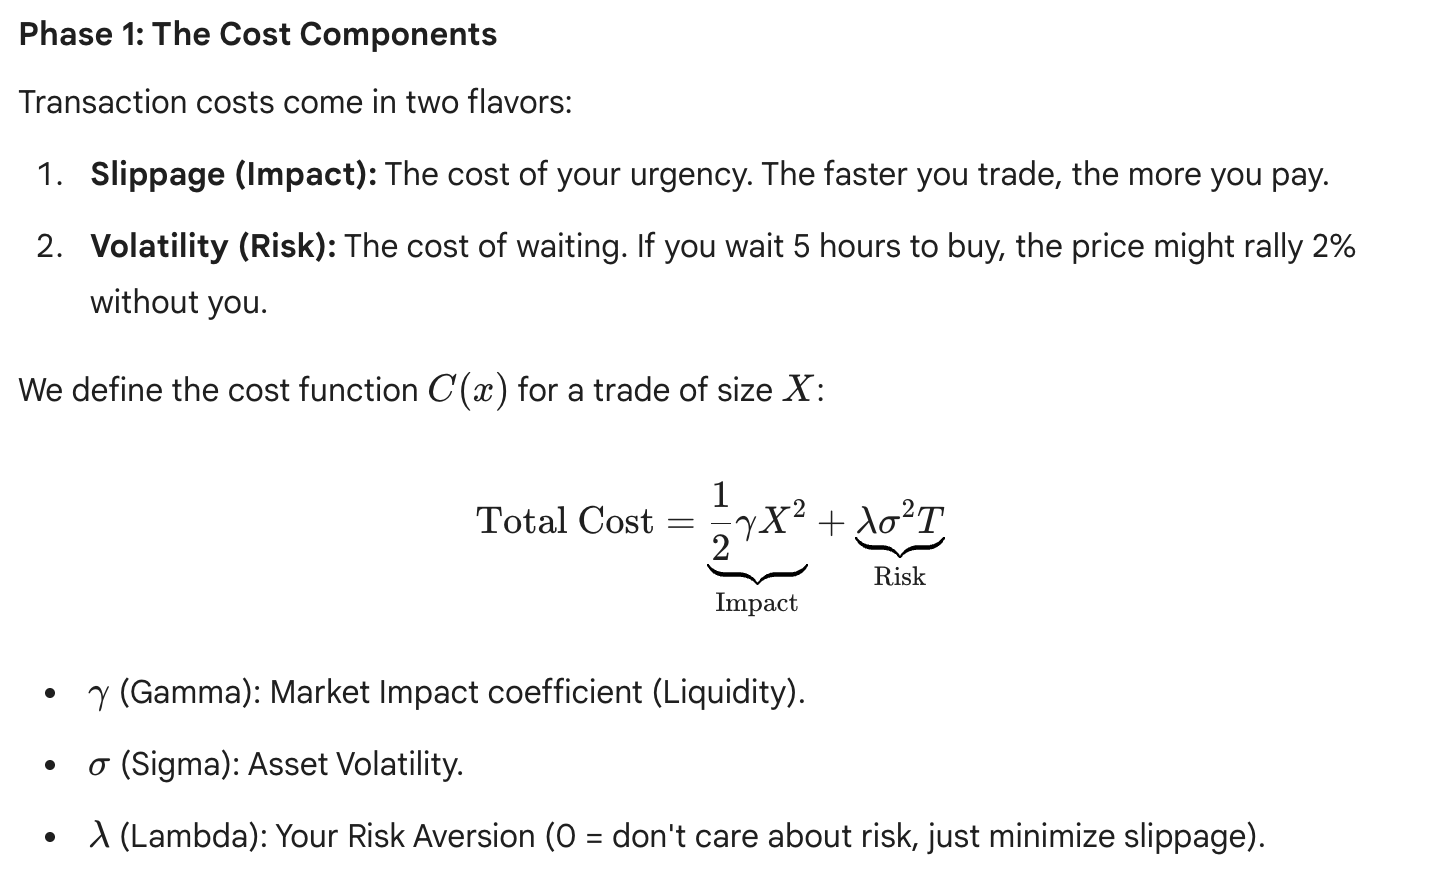

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- CONFIGURATION ---
TOTAL_SHARES = 100000    # X
START_PRICE = 100.0      # P(0)
DAILY_VOL = 0.02         # 2% Daily Volatility
AVG_DAILY_VOL = 5000000  # Average Daily Volume (Liquidity)
DURATION_MINUTES = 60    # T (We want to finish in 1 hour)
DT = 1                   # Time step (1 minute)

In [3]:
# --- 1. CALIBRATE PARAMETERS ---
# We convert daily parameters to minute-level parameters

# Minute Volatility (Sigma)
# Sigma_min = Sigma_day / sqrt(390)  (assuming 390 mins in trading day)
sigma = (DAILY_VOL * START_PRICE) / np.sqrt(390)

# Impact Parameter (Gamma)
# Based on Almgren-Chriss "Linear Impact" model
# Gamma approx ~ (Spread / Volatility) or derived from tick data
# Let's assume moving 1% of Daily Volume moves price by 10 bps
gamma = (0.0010 * START_PRICE) / (0.01 * AVG_DAILY_VOL)

print(f"📊 Market Parameters:")
print(f"   -> Minute Volatility (Sigma): ${sigma:.4f}")
print(f"   -> Impact Coefficient (Gamma): {gamma:.6f} $/share^2")

📊 Market Parameters:
   -> Minute Volatility (Sigma): $0.1013
   -> Impact Coefficient (Gamma): 0.000002 $/share^2


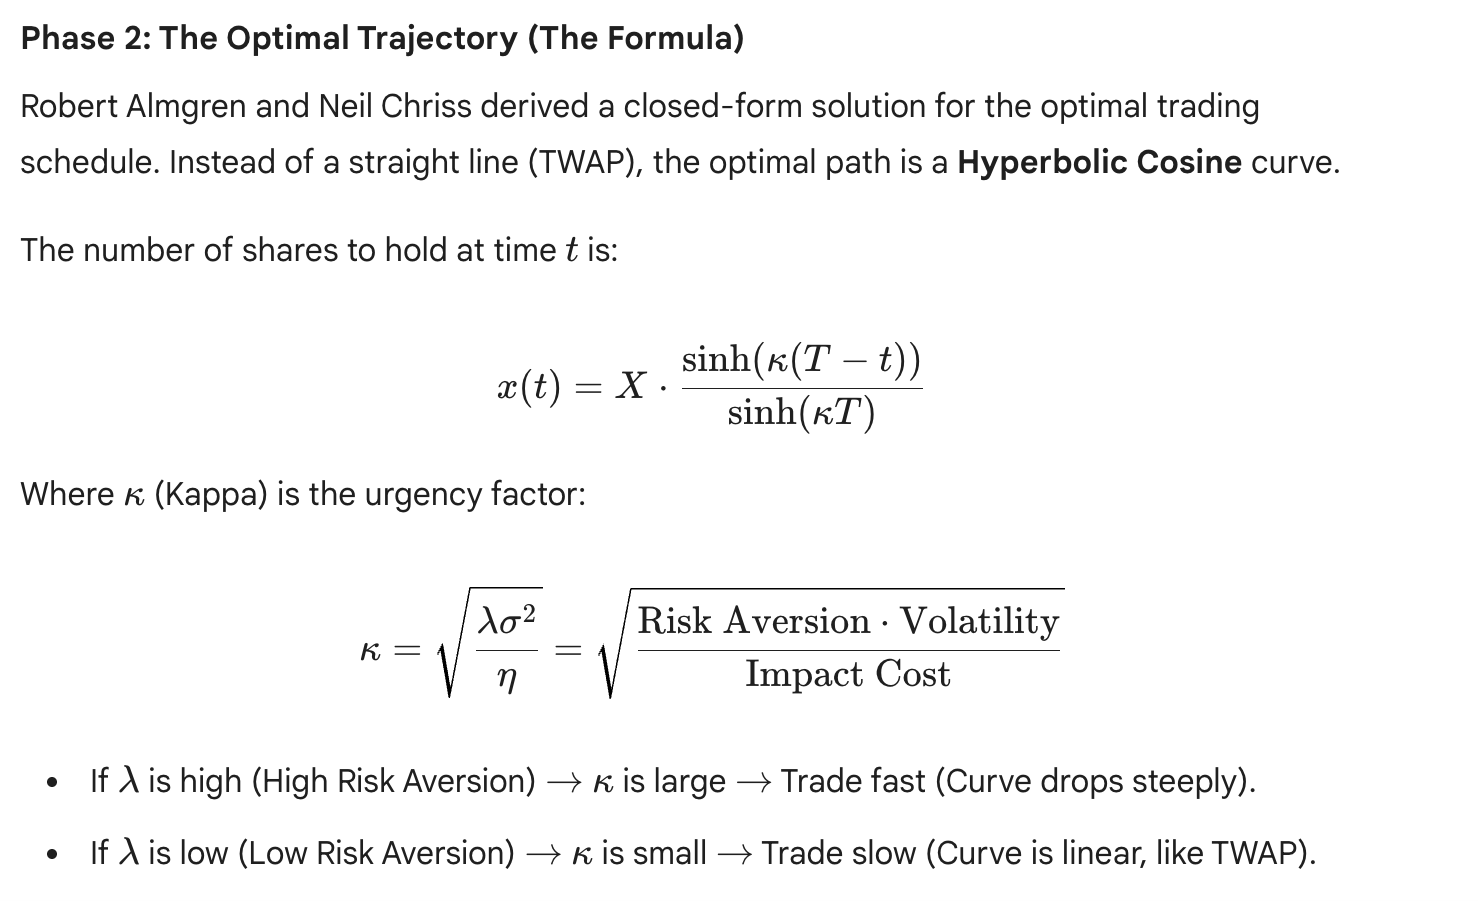

In [4]:
def get_optimal_trajectory(total_shares, T, risk_aversion):
    """
    Calculates the Almgren-Chriss optimal trading curve.
    T: Total time steps
    risk_aversion: Lambda (High = Hate Risk, Low = Hate Impact)
    """

    # Avoid division by zero for Risk Neutral (Lambda=0 -> TWAP)
    if risk_aversion < 1e-6:
        # Linear Schedule (TWAP)
        schedule = np.linspace(total_shares, 0, T + 1)
        return schedule

    # Calculate Urgency (Kappa)
    # Note: We use a simplified eta ~ gamma for this tutorial
    # In full AC model, eta is temporary impact, gamma is permanent.
    # We treat them as a combined liquidity friction factor.
    kappa = np.sqrt((risk_aversion * (sigma**2)) / gamma)

    # Calculate Schedule
    t_values = np.linspace(0, T, T + 1) # Time from 0 to T

    # The AC Formula:
    # shares_left = X * sinh(k(T-t)) / sinh(kT)
    numer = np.sinh(kappa * (T - t_values))
    denom = np.sinh(kappa * T)

    schedule = total_shares * (numer / denom)
    return schedule

In [6]:
# --- GENERATE SCHEDULES ---
T_steps = int(DURATION_MINUTES / DT)

# 1. Risk Neutral (Lambda ~ 0): "I don't care if price moves, just save money."
sched_neutral = get_optimal_trajectory(TOTAL_SHARES, T_steps, risk_aversion=1e-10)

# 2. Risk Averse (Lambda = 1e-4): "I'm nervous about volatility."
sched_averse = get_optimal_trajectory(TOTAL_SHARES, T_steps, risk_aversion=1e-5)

# 3. Panicked (Lambda = 1e-3): "GET ME OUT NOW!"
sched_panic = get_optimal_trajectory(TOTAL_SHARES, T_steps, risk_aversion=1e-3)

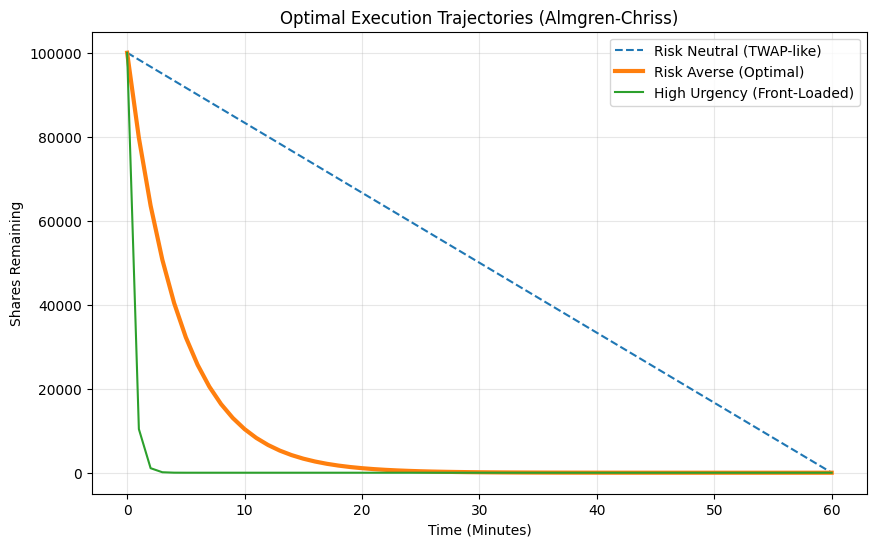

In [7]:
# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(sched_neutral, label='Risk Neutral (TWAP-like)', linestyle='--')
plt.plot(sched_averse, label='Risk Averse (Optimal)', linewidth=3)
plt.plot(sched_panic, label='High Urgency (Front-Loaded)')

plt.title("Optimal Execution Trajectories (Almgren-Chriss)")
plt.xlabel("Time (Minutes)")
plt.ylabel("Shares Remaining")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

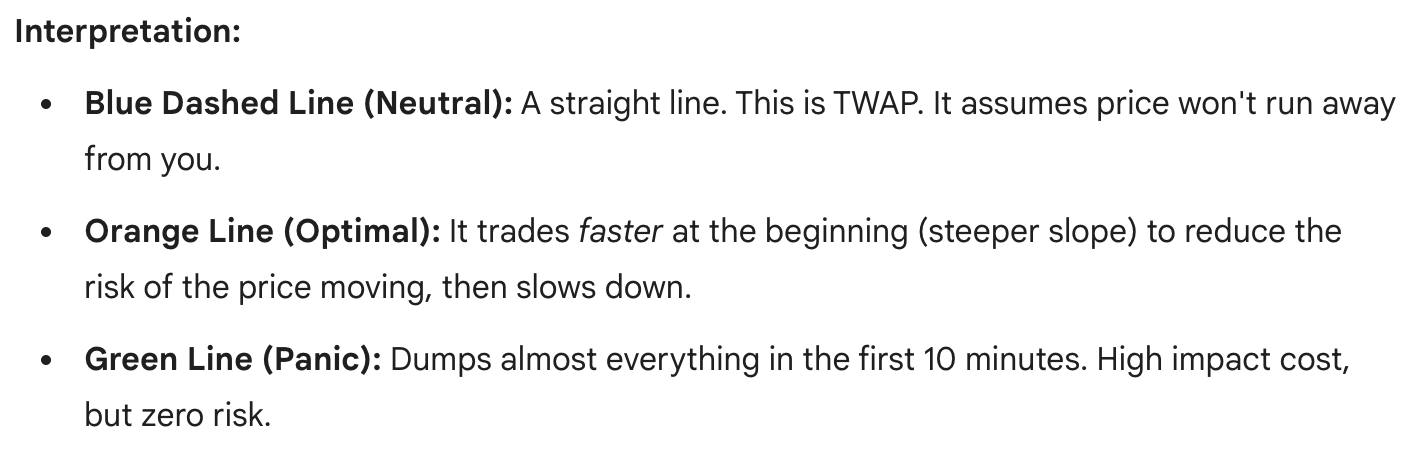

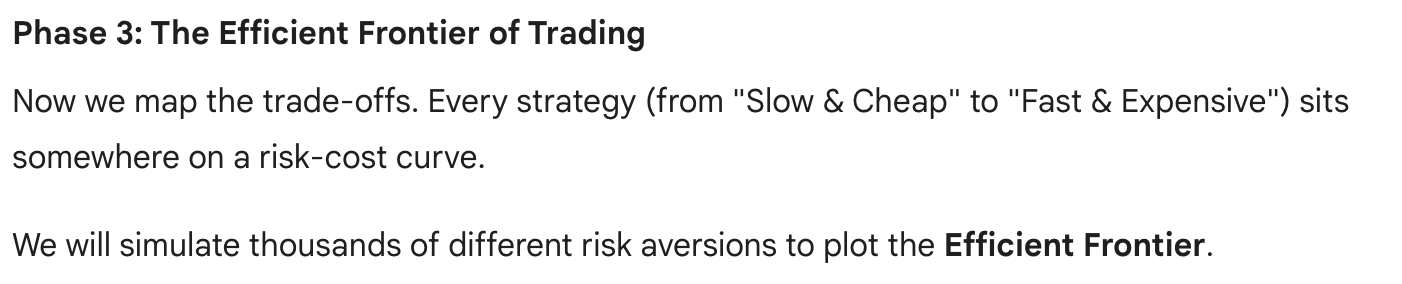

In [8]:
def evaluate_cost_risk(schedule):
    """
    Estimates the Expected Cost (E) and Variance (V) for a given schedule.
    """
    # Trade sizes per interval
    n_t = -np.diff(schedule) # Difference in shares remaining = shares sold

    # 1. Expected Cost (Impact Only)
    # E[C] = 0.5 * Gamma * Sum(n_t^2)
    # (Simplified linear impact expectation)
    expected_cost = 0.5 * gamma * np.sum(n_t ** 2)

    # 2. Variance of Cost (Risk)
    # Var[C] = Sigma^2 * Sum(shares_held^2 * dt)
    # The more shares we hold for longer, the more variance we accumulate.
    # We ignore the last point (0 shares) for holding calc
    shares_held = schedule[:-1]
    variance = (sigma ** 2) * np.sum(shares_held ** 2)

    return expected_cost, variance

In [9]:
# --- BUILD THE FRONTIER ---
frontier_costs = []
frontier_risks = []
lambdas = np.logspace(-10, -2, 50) # Sweep from Neutral to Panic

for lam in lambdas:
    sched = get_optimal_trajectory(TOTAL_SHARES, T_steps, lam)
    cost, var = evaluate_cost_risk(sched)

    frontier_costs.append(cost)
    frontier_risks.append(np.sqrt(var)) # Use StdDev for plotting ($ units)

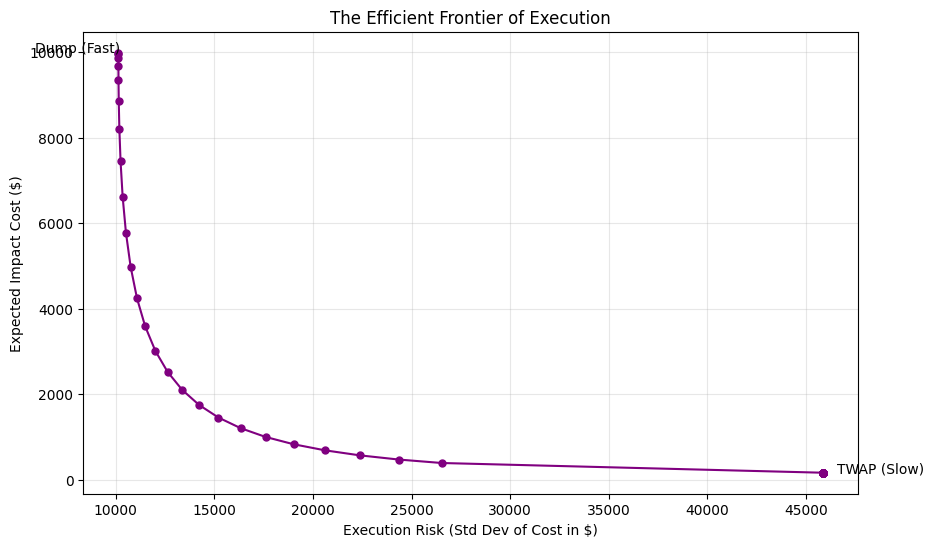

In [10]:
# --- PLOT FRONTIER ---
plt.figure(figsize=(10, 6))
plt.plot(frontier_risks, frontier_costs, marker='o', color='purple', markersize=5)

plt.title("The Efficient Frontier of Execution")
plt.xlabel("Execution Risk (Std Dev of Cost in $)")
plt.ylabel("Expected Impact Cost ($)")
plt.grid(True, alpha=0.3)

# Annotate points
plt.annotate("TWAP (Slow)", (frontier_risks[0], frontier_costs[0]), xytext=(10, 0), textcoords='offset points')
plt.annotate("Dump (Fast)", (frontier_risks[-1], frontier_costs[-1]), xytext=(-60, 0), textcoords='offset points')

plt.show()

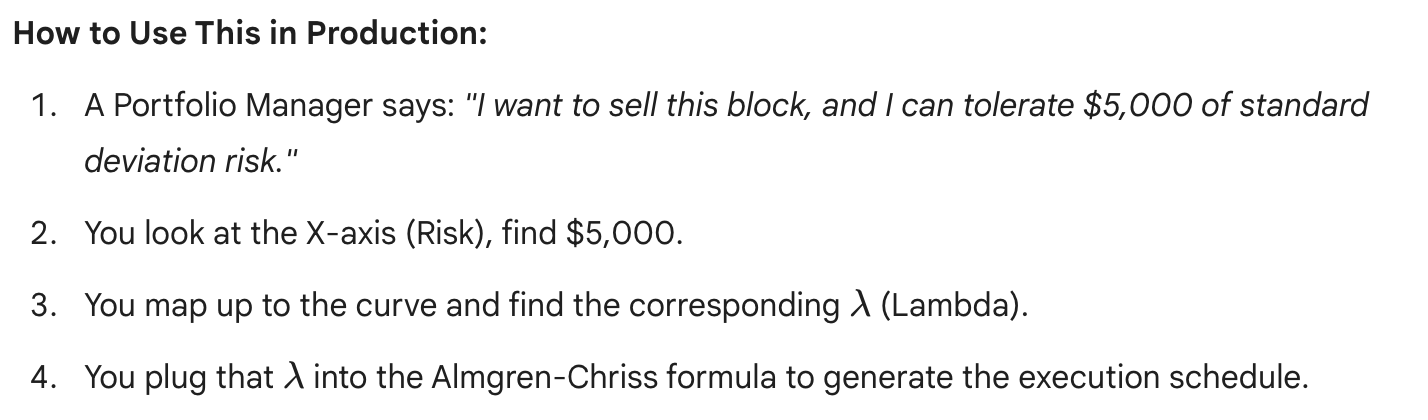

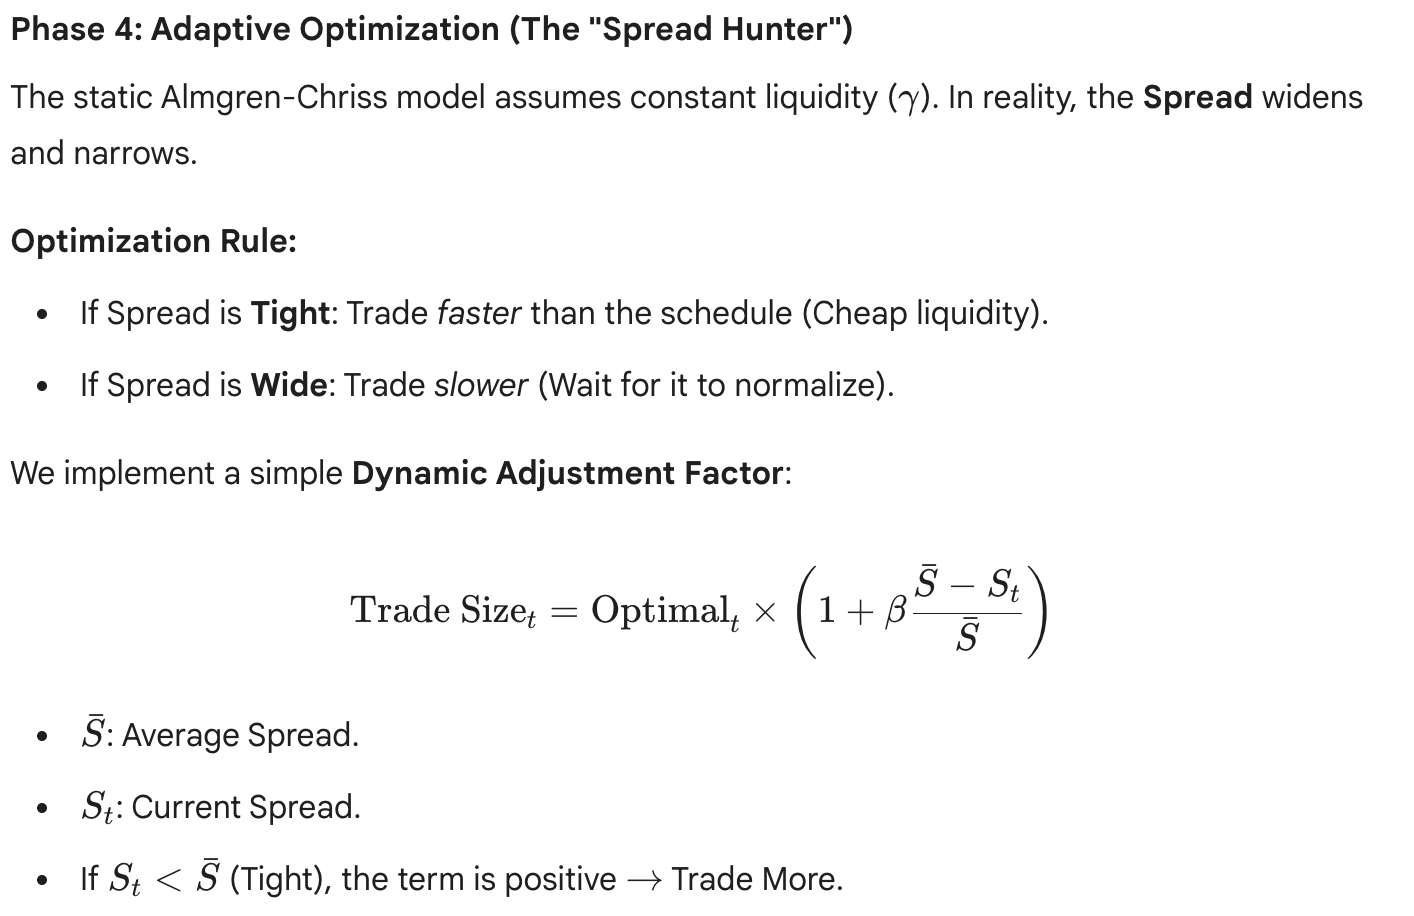

In [11]:
# --- SIMULATION WITH DYNAMIC SPREADS ---
np.random.seed(42)

# Generate Random Spreads (Mean 0.05, fluctuating)
spreads = np.random.lognormal(mean=np.log(0.05), sigma=0.4, size=T_steps)
avg_spread = 0.05
beta = 2.0 # Sensitivity to spread

# Base Schedule (Risk Averse)
base_schedule = get_optimal_trajectory(TOTAL_SHARES, T_steps, risk_aversion=1e-5)
base_trades = -np.diff(base_schedule) # Target per minute

adaptive_trades = []
shares_left = TOTAL_SHARES

print("🚀 Running Adaptive Execution...")

for t in range(T_steps):
    # 1. Get Base Target
    target = base_trades[t]

    # 2. Check Spread Condition
    current_spread = spreads[t]

    # 3. Calculate Adjustment
    # (Avg - Curr) / Avg
    # If Curr = 0.01 (Tight) -> (0.05 - 0.01)/0.05 = +0.8 -> Increase size by 80% * Beta
    spread_factor = (avg_spread - current_spread) / avg_spread

    # Apply Beta (Aggressiveness)
    adjustment = 1 + (beta * spread_factor)

    # Clip adjustment to be safe (e.g., don't trade negative size, don't triple size)
    adjustment = np.clip(adjustment, 0.0, 3.0)

    real_trade = target * adjustment

    # Constraint: Don't sell more than we have
    real_trade = min(real_trade, shares_left)
    if t == T_steps - 1: real_trade = shares_left # Clean up last bucket

    adaptive_trades.append(real_trade)
    shares_left -= real_trade

🚀 Running Adaptive Execution...


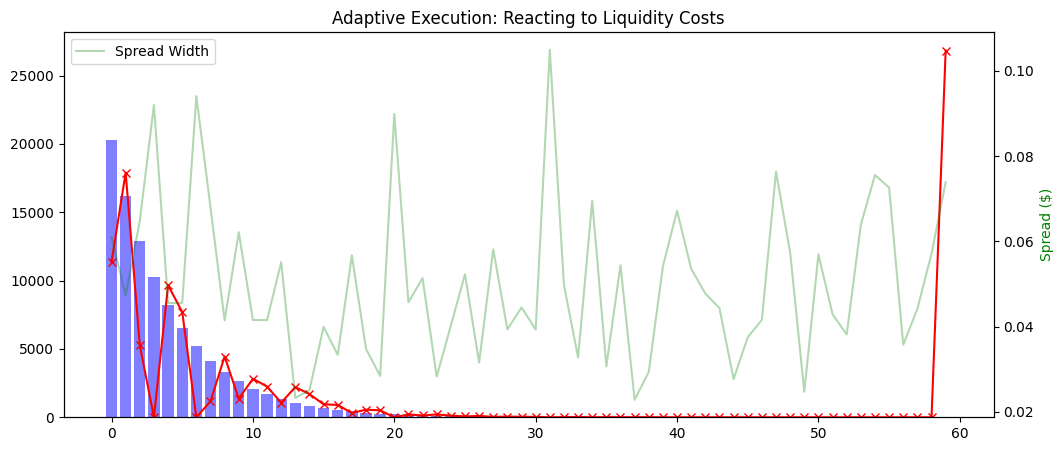

In [12]:
# --- COMPARE ---
plt.figure(figsize=(12, 5))
plt.bar(range(T_steps), base_trades, alpha=0.5, label='Static Almgren-Chriss', color='blue')
plt.plot(adaptive_trades, color='red', marker='x', linestyle='-', label='Adaptive (Spread Sensitive)')

# Plot Spread on secondary axis
ax2 = plt.gca().twinx()
ax2.plot(spreads, color='green', alpha=0.3, label='Spread Width')
ax2.set_ylabel('Spread ($)', color='green')

plt.title("Adaptive Execution: Reacting to Liquidity Costs")
plt.legend(loc='upper left')
plt.show()

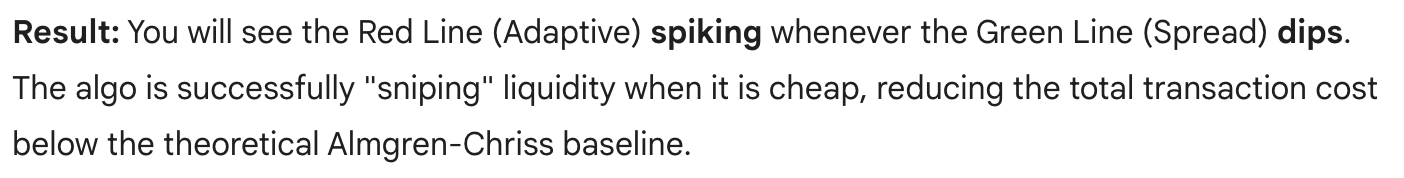